In [36]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from pathlib import Path
from skimage import io
from skimage.io import imread_collection
import datetime
import re
import builtins
import os
import imageio.v2 as imageio
from IPython.display import Image, display
from collections import defaultdict
import pandas as pd
import matplotlib.dates as mdates

In [37]:
# Functions to parse metadata from filenames

def get_led(filename: str) -> str:
    return filename.split("/")[-1].split("_")[0]

def get_fov(filename: str) -> int:
    return int(filename.split("/")[-1].split("_")[1][1:])

def get_str(filename: str) -> str:
    parts = filename.split("/")[-1].split("_")
    return " ".join([parts[0], parts[1], parts[-1].split(".")[0]])

def sort_by_time(file_list):
    timestamp_pattern = re.compile(r"(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}-\d{6})")
    timestamps = [timestamp_pattern.search(f.split("/")[-1]).group(1) for f in file_list]
    times = [datetime.datetime.strptime(ts, "%Y-%m-%d_%H-%M-%S-%f") for ts in timestamps]
    return [f for _, f in sorted(zip(times, file_list))]



def plot_window(log_df, start_time, end_time):
    recent_df = log_df[log_df["absolute_time"].between(start_time, end_time)].copy()

    print(f"Showing {len(recent_df)} rows from {start_time} to {end_time}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(recent_df["absolute_time"], recent_df["CH 2 Pressure (mbar)"], linewidth=1)
    ax1.set_ylabel("Pressure (mbar)")
    ax1.set_title("CH 2 Pressure over Time")
    ax1.grid(True, alpha=0.3)

    ax2.plot(recent_df["absolute_time"], recent_df["CH 2 Flow (ul/min)"], linewidth=1, color="orange")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Flow (ul/min)")
    ax2.set_title("CH 2 Flow over Time")
    ax2.grid(True, alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [38]:
# INPUT experiment name
experiment_name = "VTF---2026-07-10---X-87"
log_file_name = "log_1007_1402_OB1.csv"

# Path specification

base_path = Path("/mnt/large_storage/shared_storage/data/Vicen")
data_path = base_path / "data" / experiment_name
log_file = base_path / "microfluidic_logs" / log_file_name

data_path = Path("/mnt/large_storage/shared_storage/data/Vicen/data/VTF---2026-07-10---X-87/overnightdata")

output_path = base_path / "GIFs" / experiment_name
output_path.mkdir(parents=True, exist_ok=True)

if not data_path.exists():
    raise FileNotFoundError(f"data_path does not exist: {data_path}")

print(f"  data_path        = {data_path}")
print(f"  experiment_name  = {experiment_name}")
print(f"  log_file_name    = {log_file_name}")
print(f"  output_path      = {output_path}")

  data_path        = /mnt/large_storage/shared_storage/data/Vicen/data/VTF---2026-07-10---X-87/overnightdata
  experiment_name  = VTF---2026-07-10---X-87
  log_file_name    = log_1007_1402_OB1.csv
  output_path      = /mnt/large_storage/shared_storage/data/Vicen/GIFs/VTF---2026-07-10---X-87


In [39]:
# Load the CSV file with error handling
try:
    log_df = pd.read_csv(log_file)
except Exception as e:
    raise RuntimeError(f"Failed to read CSV '{log_file}': {e}")

# Parse the log file name to extract the start time
# Format: log_DDMM_HHMM (DD = day, MM = month)
match = re.search(r'log_(\d{4})_(\d{4})', log_file_name)
if not match:
    raise ValueError(f"log_file_name does not match expected pattern: {log_file_name}")
day_month = match.group(1)
# split day_month into day and month
day = day_month[:2]
month = day_month[2:]
hour_minute = match.group(2)

# Create a datetime object for the start time (using extracted day and month)
start_time = datetime.datetime.strptime(f"2026-{month}-{day} {hour_minute[:2]}:{hour_minute[2:]}", "%Y-%m-%d %H:%M")

# Detect the time column (tolerant to small name variations)
time_col = None
for c in log_df.columns:
    if c.strip().lower().startswith('time'):
        time_col = c
        break
if time_col is None:
    raise KeyError(f"No time column found in CSV. Available columns: {list(log_df.columns)}")

# Ensure numeric time values
log_df[time_col] = pd.to_numeric(log_df[time_col], errors='coerce')
if log_df[time_col].isna().any():
    raise ValueError(f"Non-numeric values found in time column '{time_col}'")

# Add the absolute_time column by adding the time (s) column to the start time
log_df['absolute_time'] = log_df[time_col].apply(lambda t: start_time + datetime.timedelta(seconds=float(t)))

# Diagnostic messages
print(f"✓ Loaded CSV file from: {log_file}")
print(f"  Detected time column: {time_col}")
print(f"  Parsed start_time: {start_time}")
print(f"  Time start: {log_df['absolute_time'].iloc[0]}")
print(f"  Time finish: {log_df['absolute_time'].iloc[-1]}")
print(f"  Total time: {log_df[time_col].iloc[-1]:.2f} seconds")
print(f"  Number of data points: {len(log_df)}")


# Overview of log_df
print("Shape:", log_df.shape)
display(log_df.head())

✓ Loaded CSV file from: /mnt/large_storage/shared_storage/data/Vicen/microfluidic_logs/log_1007_1402_OB1.csv
  Detected time column: Time (s)
  Parsed start_time: 2026-07-10 14:02:00
  Time start: 2026-07-10 14:02:00.000850
  Time finish: 2026-07-11 23:27:58.000859
  Total time: 120358.00 seconds
  Number of data points: 120359
Shape: (120359, 20)


,Time (s),CH 1 Pressure (mbar),CH 1 Flow (ul/min),CH 1 Medium left (ml),CH 1 Mode,CH 1 Reference flow (ul/min),CH 1 Constant pressure (mbar),CH 1 P gain,CH 1 I gain,CH 1 D gain,CH 2 Pressure (mbar),CH 2 Flow (ul/min),CH 2 Medium left (ml),CH 2 Mode,CH 2 Reference flow (ul/min),CH 2 Constant pressure (mbar),CH 2 P gain,CH 2 I gain,CH 2 D gain,absolute_time
0,0.000850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.334698,-0.107407,50.000000,0,42.0,NaN,0.05,0.1,0.05,2026-07-10 14:02:00.000850
1,1.000281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.334698,-0.511111,50.000009,0,42.0,NaN,0.05,0.1,0.05,2026-07-10 14:02:01.000281
2,2.001029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.634328,-0.518519,50.000017,0,42.0,NaN,0.05,0.1,0.05,2026-07-10 14:02:02.001029
3,3.000751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.938919,-0.537037,50.000026,0,42.0,NaN,0.05,0.1,0.05,2026-07-10 14:02:03.000751
4,4.001111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.403436,-0.570370,50.000036,0,42.0,NaN,0.05,0.1,0.05,2026-07-10 14:02:04.001111


Original rows: 120359
Trimmed rows:   120359


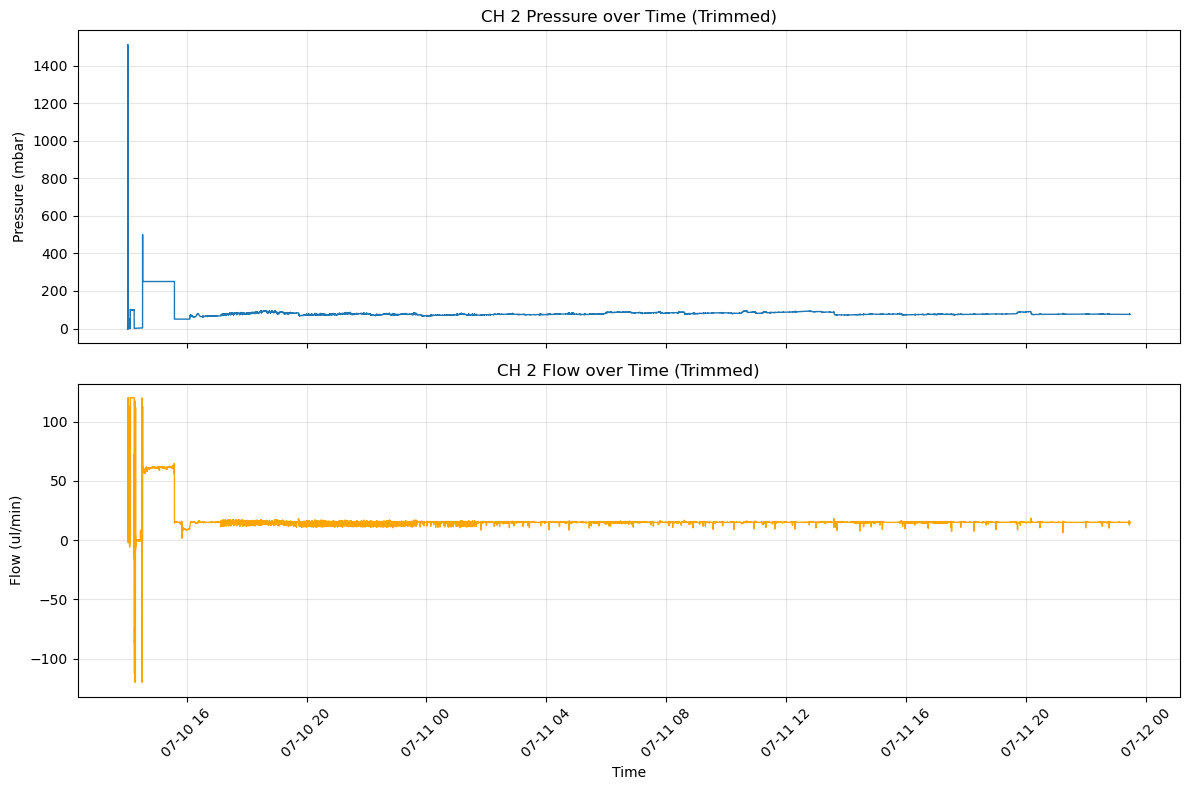

In [40]:
trimmed_df = log_df[
    log_df['CH 1 Constant pressure (mbar)'].isna() &
    log_df['CH 2 Constant pressure (mbar)'].isna()
].copy()

print(f"Original rows: {len(log_df)}")
print(f"Trimmed rows:   {len(log_df)}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(log_df['absolute_time'], log_df['CH 2 Pressure (mbar)'], linewidth=1)
ax1.set_ylabel('Pressure (mbar)')
ax1.set_title('CH 2 Pressure over Time (Trimmed)')
ax1.grid(True, alpha=0.3)

ax2.plot(log_df['absolute_time'], log_df['CH 2 Flow (ul/min)'], linewidth=1, color='orange')
ax2.set_xlabel('Time')
ax2.set_ylabel('Flow (ul/min)')
ax2.set_title('CH 2 Flow over Time (Trimmed)')
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:

# File discovery

image_patterns = ["*.tif", "*.tiff", "*.ome.tif", "*.ome.tiff"]
filenames = []
for pattern in image_patterns:
    filenames.extend(data_path.rglob(pattern)) # recursively search for image files

filenames = sorted({str(f) for f in filenames})

print(f"Loaded {len(filenames)} images \n")

# Diagnostic: check file counts and timestamp uniqueness per LED/FOV

files_by_led = defaultdict(list)
files_by_led_by_fov = defaultdict(lambda: defaultdict(list))


for f in filenames:
    led = get_led(f)
    fov = get_fov(f)
    files_by_led[led].append(f)
    files_by_led_by_fov[led][fov].append(f)

print(f"Files per LED:")

for led in sorted(files_by_led):
    print(f"{led}: {len(files_by_led[led])} files")
    # for fov in sorted(files_by_led_by_fov[led]):
    #     print(f"  FOV {fov}: {len(files_by_led_by_fov[led][fov])} files")

Loaded 1322 images 

Files per LED:
LED450NM: 22 files
LED515NM: 617 files
LED565NM: 22 files
LED645NM: 22 files
LEDOVERHEAD: 22 files
LEDOVERHEADTIGER: 617 files


In [42]:
# # ================================================================
# # Identify corrupted TIFFs (read test)
# # ================================================================

# from tqdm import tqdm  # progress bar
# import warnings

# # Configure read test: try full read, fall back to header-only if needed
# def _read_test(path_str):
#     try:
#         # Read to force decode; if image is large, this may be slow but reliable
#         _ = io.imread(path_str)
#         return True, None
#     except Exception as exc:
#         return False, exc

# bad_files = []
# good_files = []

# # Optional: silence skimage warnings that do not indicate corruption
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     for f in tqdm(filenames, desc="Validating TIFFs"):
#         ok, exc = _read_test(f)
#         if ok:
#             good_files.append(f)
#         else:
#             bad_files.append((f, exc))

# print(f"Total files: {len(filenames)}")
# print(f"Good files : {len(good_files)}")
# print(f"Bad files  : {len(bad_files)}")

# if bad_files:
#     print("\nBad files (first 20):")
#     for f, exc in bad_files[:20]:
#         print(f"- {Path(f).name}: {type(exc).__name__} - {exc}")

# # Use this filtered list for downstream processing if desired
# filenames = good_files

In [43]:
# INPUT LED selection (multiple may be selected, e.g., ["LED515NM", "LEDOVERHEADTIGER"])

#sel_led = ["LED515NM", "LEDOVERHEADTIGER"]
sel_led = ["LED515NM"]

# Select LED
for led in sel_led:
    if not (led.startswith('LED') and (led.endswith('NM') or led.endswith('OVERHEAD') or led.endswith('OVERHEADTIGER'))):
        raise ValueError(f"Invalid LED format: {led}. Expected format: LED<wavelength>NM or LEDOVERHEAD")

print(f"Selected LEDs = {sel_led}")

# Group filenames by position for the selected LEDs
fovs_by_led = {}
filenames_by_fov_by_led = {}

for led in sel_led:
    fovs_by_led[led] = np.unique([get_fov(f) for f in filenames if get_led(f) == led])
    filenames_by_fov_by_led[led] = {
        fov: sort_by_time([f for f in filenames if get_led(f) == led and get_fov(f) == fov])
        for fov in fovs_by_led[led]
    }

# Load images per position per LED
imgs_by_led = {}
fov_index_by_led = {}

for led in sel_led:
    imgs_by_led[led] = []
    fov_index_by_led[led] = {}
    for i, fov in enumerate(fovs_by_led[led]):
        if filenames_by_fov_by_led[led][fov]:
            imgs_by_led[led].append(imread_collection(filenames_by_fov_by_led[led][fov]))
            fov_index_by_led[led][fov] = i


# Diagnostic: check file counts and timestamp uniqueness per LED/FOV

for led in sel_led:
    print(f"\n{led} - {len(fovs_by_led[led])} total files found accross {len(fovs_by_led[led])} FOVs")
    for fov in fovs_by_led[led]:
        files = filenames_by_fov_by_led[led][fov]
        if len(files) <= 1:
            print(f"  FOV {fov}: only {len(files)} file(s) found; continuing")
            continue
        print(f"  FOV {fov}: files={len(files)}")

Selected LEDs = ['LED515NM']

LED515NM - 22 total files found accross 22 FOVs
  FOV 0: files=29
  FOV 1: files=28
  FOV 2: files=28
  FOV 3: files=28
  FOV 4: files=28
  FOV 5: files=28
  FOV 6: files=28
  FOV 7: files=28
  FOV 8: files=28
  FOV 9: files=28
  FOV 10: files=28
  FOV 11: files=28
  FOV 12: files=28
  FOV 13: files=28
  FOV 14: files=28
  FOV 15: files=28
  FOV 16: files=28
  FOV 17: files=28
  FOV 18: files=28
  FOV 19: files=28
  FOV 20: files=28
  FOV 21: files=28


Plotting FOV no 3


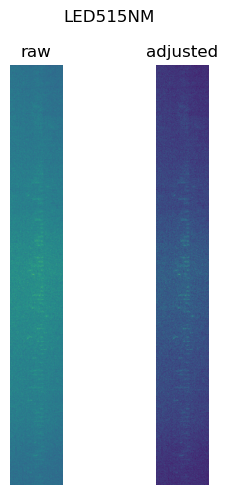

In [59]:
# INPUT image adjustment parameters

fov_to_display = 3
v_min_perc = [5]
v_max_perc = [100]

#y_min, y_max, x_min, x_max = 0, 30000, 0, 3000
y_min, y_max, x_min, x_max = 0, 3200, 900, 1300

if len(v_min_perc) != len(sel_led) or len(v_max_perc) != len(sel_led):
    raise ValueError(f"Expected {len(sel_led)} values in v_min_perc and v_max_perc - one per selected LED")

print(f"Plotting FOV no {fov_to_display}")

# Display cropped images with raw and adjusted contrast per LED

for i, led in enumerate(sel_led):
    if fov_to_display not in filenames_by_fov_by_led[led]:
        fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        axes[0].set_axis_off()
        axes[1].set_axis_off()
        fig.suptitle(led)
        axes[0].set_title("FOV not found")
        plt.tight_layout()
        plt.show()
        continue

    first_file = filenames_by_fov_by_led[led][fov_to_display][0]
    img = io.imread(first_file)[y_min:y_max, x_min:x_max]
    v_min = np.percentile(img, v_min_perc[i])
    v_max = np.percentile(img, v_max_perc[i])

    fig, axes = plt.subplots(1, 2, figsize=(4, 5))
    fig.suptitle(led)
    axes[0].imshow(img, cmap="viridis")
    axes[0].set_title("raw")

    axes[1].imshow(img, cmap="viridis", vmin=v_min, vmax=v_max)
    axes[1].set_title("adjusted")

    axes[0].axis("off")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [60]:
# Apply cropping

roi = [y_min, y_max, x_min, x_max]

# INPUT gif parameters (multiple can be selected e.g., [3, 4, 5] for FOVs 3, 4, and 5)

fovs = [1,2,3,4,5]
#fovs = np.unique(np.concatenate([fovs_by_led[led] for led in sel_led]))

fps = 1

timelim = None # minutes; set to a number to cap GIF length


FOV 1 frame counts: {'LED515NM': 28}
Generating FOV1 gif...
FOV1 gif generated and saved!
FOV 2 frame counts: {'LED515NM': 28}
Generating FOV2 gif...
FOV2 gif generated and saved!
FOV 3 frame counts: {'LED515NM': 28}
Generating FOV3 gif...
FOV3 gif generated and saved!
FOV 4 frame counts: {'LED515NM': 28}
Generating FOV4 gif...
FOV4 gif generated and saved!
FOV 5 frame counts: {'LED515NM': 28}
Generating FOV5 gif...
FOV5 gif generated and saved!


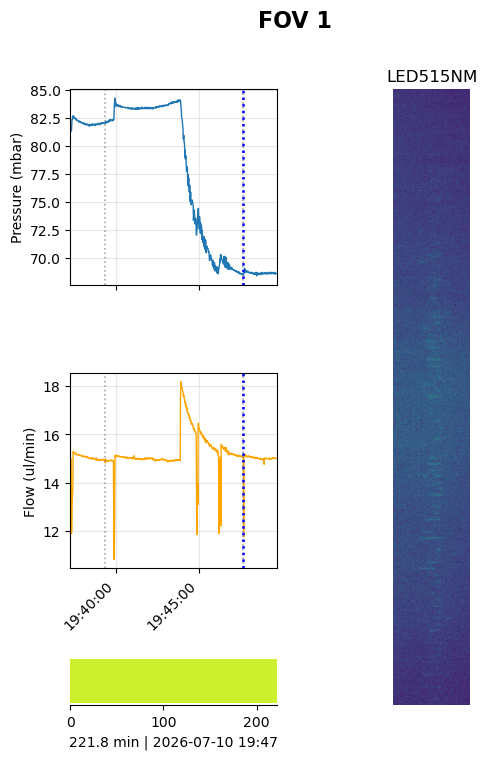

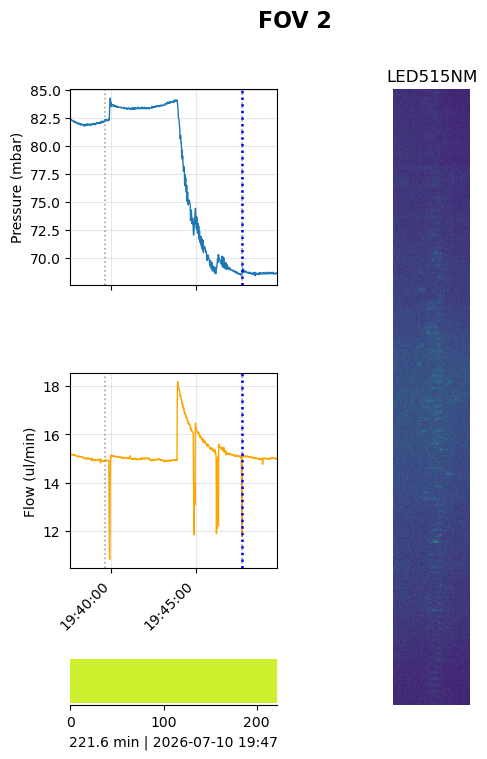

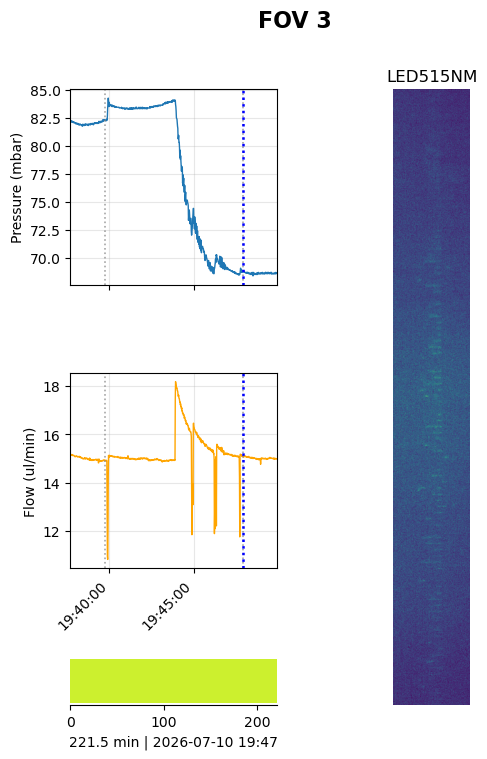

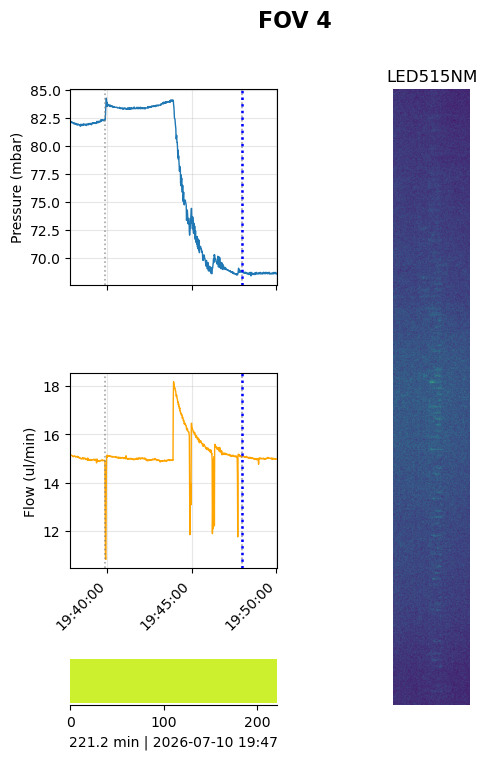

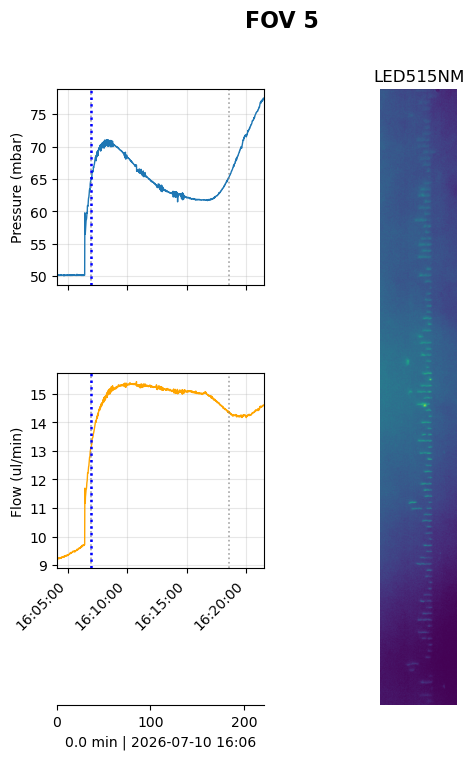

In [61]:
# Fraction of the prev→next span to pad on each side of the window
plot_buffer_frac = 0.25

# Define timestamp extraction pattern and format
timestamp_pattern = re.compile(r"(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}-\d{6})")
timestamp_format = "%Y-%m-%d_%H-%M-%S-%f"

for p in fovs:
    frame_images_by_led = {}
    times_by_led = {}

    for led in sel_led:
        # Skip FOV if not available for this LED
        if p not in filenames_by_fov_by_led[led]:
            print(f"FOV {p} not found for LED {led}; skipping.")
            continue
        
        frame_files = filenames_by_fov_by_led[led][p]
        fov_index = fov_index_by_led[led][p]
        frame_images_by_led[led] = [
            image[roi[0]:roi[1], roi[2]:roi[3]] for image in imgs_by_led[led][fov_index]
        ]

        timestamps = [timestamp_pattern.search(Path(f).name).group(1) for f in frame_files]
        times_by_led[led] = [datetime.datetime.strptime(ts, timestamp_format) for ts in timestamps]

    # Skip if no images loaded for this FOV
    if not times_by_led:
        print(f"FOV {p}: no images found; skipping.")
        continue
    
    n_frames_by_led = {led: len(frame_images_by_led[led]) for led in times_by_led.keys()}
    print(f"FOV {p} frame counts: {n_frames_by_led}")

    n_frames = max(n_frames_by_led.values()) if n_frames_by_led else 0

    time_led = max(n_frames_by_led, key=n_frames_by_led.get)
    t0 = times_by_led[time_led][0]
    minutes = [(t - t0).total_seconds() / 60.0 for t in times_by_led[time_led]]
    total_minutes = minutes[-1] if minutes else 0.0

    if timelim is not None and minutes and minutes[-1] > timelim:
        cutoff_idx = next((i for i, m in enumerate(minutes) if m > timelim), len(minutes))
        if cutoff_idx == 0:
            print(f"FOV {p} exceeds timelim before first frame; skipping.")
            continue
        n_frames = min(n_frames, cutoff_idx)
        total_minutes = timelim

    # Layout: images on the right, plots (top) and bar (bottom) on the left
    fig = plt.figure(figsize=(6 * len(sel_led), 8))
    fig.suptitle(f"FOV {p}", fontsize=16, fontweight="bold")
    outer = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.25)

    # Left column: pressure, flow, bar stacked
    left = outer[0, 0].subgridspec(3, 1, height_ratios=[4, 4, 1], hspace=0.6)
    ax_pressure = fig.add_subplot(left[0])
    ax_flow = fig.add_subplot(left[1])
    ax_bar = fig.add_subplot(left[2])

    # Right column: images side by side
    right = outer[0, 1].subgridspec(1, len(sel_led), wspace=0.05)
    ax_imgs = [fig.add_subplot(right[0, i]) for i in range(len(sel_led))]

    def update(frame):
        for ax in ax_imgs:
            ax.clear()
        ax_pressure.clear()
        ax_flow.clear()
        ax_bar.clear()

        for i, led in enumerate(sel_led):
            if led not in frame_images_by_led:
                continue
            frame_idx = min(frame, len(frame_images_by_led[led]) - 1)
            frame_img = frame_images_by_led[led][frame_idx]
            v_min = np.percentile(frame_img, v_min_perc[i])
            v_max = np.percentile(frame_img, v_max_perc[i])
            ax_imgs[i].imshow(frame_img, cmap="viridis", vmin=v_min, vmax=v_max)
            ax_imgs[i].axis("off")
            ax_imgs[i].set_title(led)

        # --- Timing reference (LED with most frames) ---
        times_ref = times_by_led[time_led]
        n_ref = len(times_ref)
        cur_idx = min(frame, n_ref - 1)
        prev_idx = max(cur_idx - 1, 0)
        next_idx = min(cur_idx + 1, n_ref - 1)

        t_prev = times_ref[prev_idx]
        t_cur = times_ref[cur_idx]
        t_next = times_ref[next_idx]

        # Window = [prev, next] padded by a buffer on each side
        span = t_next - t_prev
        if span.total_seconds() <= 0:
            buffer = datetime.timedelta(seconds=30)  # fallback for first/last/single frame
        else:
            buffer = span * plot_buffer_frac
        window_start = t_prev - buffer
        window_end = t_next + buffer

        recent_df = log_df[log_df["absolute_time"].between(window_start, window_end)]

        # --- Pressure ---
        ax_pressure.plot(recent_df["absolute_time"], recent_df["CH 2 Pressure (mbar)"], linewidth=1)
        ax_pressure.set_ylabel("Pressure (mbar)")
        ax_pressure.grid(True, alpha=0.3)
        ax_pressure.set_xlim(window_start, window_end)
        ax_pressure.tick_params(labelbottom=False)  # hide x labels on top plot

        # --- Flow ---
        ax_flow.plot(recent_df["absolute_time"], recent_df["CH 2 Flow (ul/min)"], linewidth=1, color="orange")
        ax_flow.set_ylabel("Flow (ul/min)")
        ax_flow.grid(True, alpha=0.3)
        ax_flow.set_xlim(window_start, window_end)
        ax_flow.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
        for label in ax_flow.get_xticklabels():
            label.set_rotation(45)
            label.set_ha("right")

        # --- Vertical lines at prev / current / next image times ---
        for ax in (ax_pressure, ax_flow):
            ax.axvline(t_prev, color="gray", linestyle=":", linewidth=1.2, alpha=0.7)   # past
            ax.axvline(t_next, color="gray", linestyle=":", linewidth=1.2, alpha=0.7)   # future
            ax.axvline(t_cur, color="blue", linestyle=":", linewidth=1.8)               # present

        # --- Time bar ---
        time_idx = min(frame, len(minutes) - 1)
        ax_bar.barh([0], [minutes[time_idx]], height=0.6, color="#ccf02e")
        ax_bar.set_xlim(0, max(total_minutes, 1e-6))
        ax_bar.set_yticks([])
        abs_time = times_by_led[time_led][time_idx].strftime("%Y-%m-%d %H:%M")
        ax_bar.set_xlabel(f"{minutes[time_idx]:.1f} min | {abs_time}")
        ax_bar.spines["top"].set_visible(False)
        ax_bar.spines["right"].set_visible(False)
        ax_bar.spines["left"].set_visible(False)

    animation = FuncAnimation(fig, update, frames=range(0, n_frames), interval=200)

    print(f"Generating FOV{p} gif...")
    gif_path = output_path / f"{experiment_name}_{sel_led}_FOV{p}.gif"
    animation.save(gif_path, fps=fps)
    print(f"FOV{p} gif generated and saved!")